# Deciding Factors for the US Election in 2016
## Linus, Casimir, Rieke
## ESC403, Project Proposal

## Preparation

### import packages

In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np

### import new packages (then copy to the code chunk above)

In [18]:
#import numpy as np

## load and first look at data 

In [2]:
df = pd.read_csv("data/VOTER_Survey_December16_Release1.csv",low_memory=False, sep = ",")

In [3]:
print(df.shape)

(8000, 668)


In [21]:
#possibility to replace empty strings with nans
df_nan = df.replace(r'^\s*$', np.nan, regex=True)

## first data exploration

### plot histogram code used for function

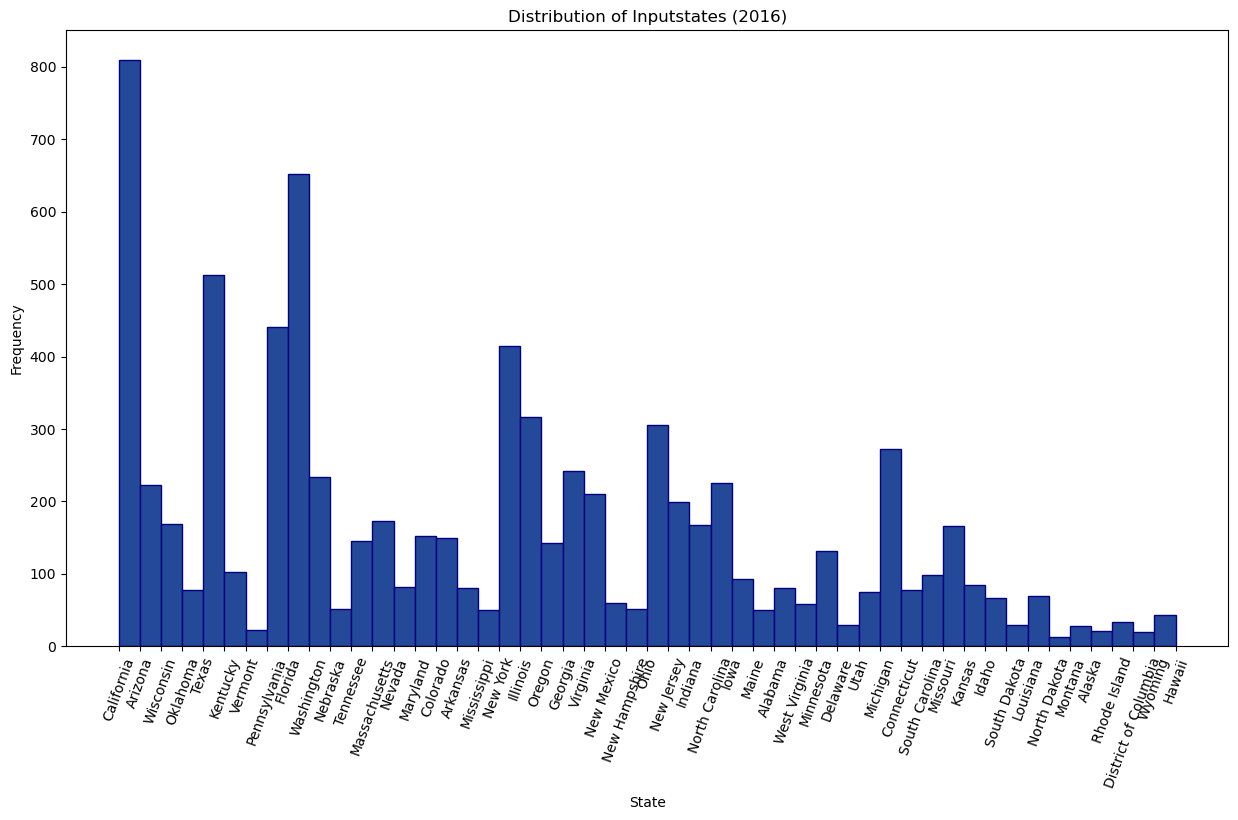

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plt.hist(df["inputstate_2016"], bins = 50, color = "#244999", edgecolor='navy' )
plt.title("Distribution of Inputstates (2016)")
plt.xlabel("State")
plt.xticks(rotation = 70)
plt.ylabel("Frequency")
#plt.savefig("C:/Users/rieke/OneDrive/Documents/FS26/datascience/project/plot_images/hist_states_2016.png", dpi = 300)
plt.show()

### funciton to plots and save histograms

In [41]:
def hist(colname, df = df, bins = 20, size = (15,8)):
    """
    colname must be string 
    all others are optional 

    """
    plt.figure(figsize= size)
    plt.hist(df[colname], bins = bins, color = "#244999", alpha=0.6, edgecolor='navy' )
    plt.title("Distribution of " + colname )
    plt.xlabel(colname)
    plt.xticks(rotation = 70)
    plt.ylabel("Frequency")
    #plt.savefig("C:/Users/rieke/OneDrive/Documents/FS26/datascience/project/plot_images/hist_" + colname + ".png", dpi = 300)
    plt.show()

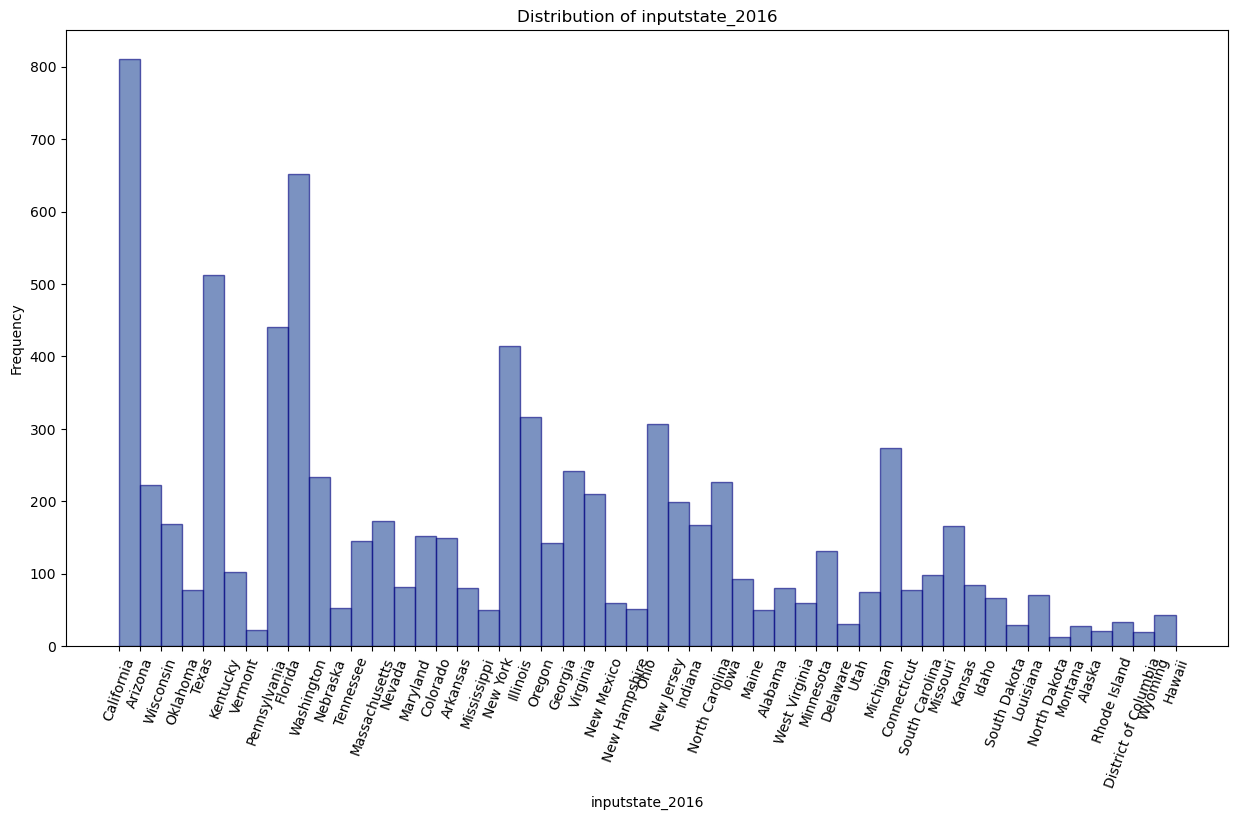

In [42]:
hist("inputstate_2016", bins = 50)

### some columns need to be converted to strings to plot histograms

In [ ]:
df["occupation"] = df["employ_2016"].astype(str)
df["victim"] = df["victim_12mo_2016"].astype(str)
df["education"] = df["educ_2016"].astype(str)
df["marstat"] = df["marstat_2016"].astype(str)
df["children"] = df["child18_2016"].astype(str)

In [ ]:
hist("children")

### contengency table 

In [ ]:
crosstab_party_occupation = pd.crosstab(df['PARTY_AGENDAS_rand_2016'],
                            df['occupation'], 
                               margins = False)
print(crosstab_party_occupation)
#crosstab_party_occupation.to_csv('C:/Users/rieke/OneDrive/Documents/FS26/datascience/project/crosstab_results.csv', index=True)

In [ ]:
# healthcov2_2016

crosstab_party_occupation = pd.crosstab(df['PARTY_AGENDAS_rand_2016'],
                            df['healthcov2_2016'], 
                               margins = False)
print(crosstab_party_occupation)
#crosstab_party_occupation.to_csv('C:/Users/rieke/OneDrive/Documents/FS26/datascience/project/crosstab_results_healthcov2_2016.csv', index=True)

### take a look at how long it took people to fill out the survey 
convert times 

In [43]:
df["start_time"] = pd.to_datetime(df["starttime_2016"], format='mixed')

In [44]:
df["end_time"] = pd.to_datetime(df["endtime_2016"], format='mixed')

In [45]:
df["duration_minutes"] = (df["end_time"] - df["start_time"]).dt.total_seconds() / 60

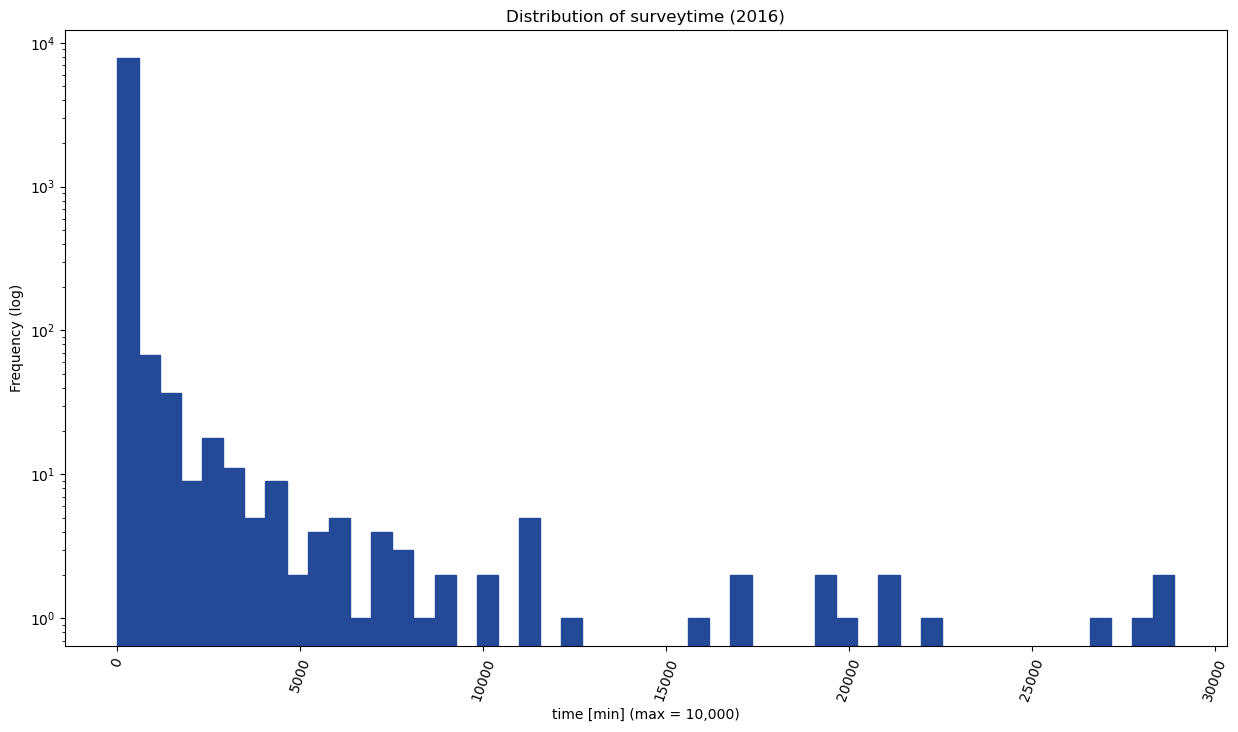

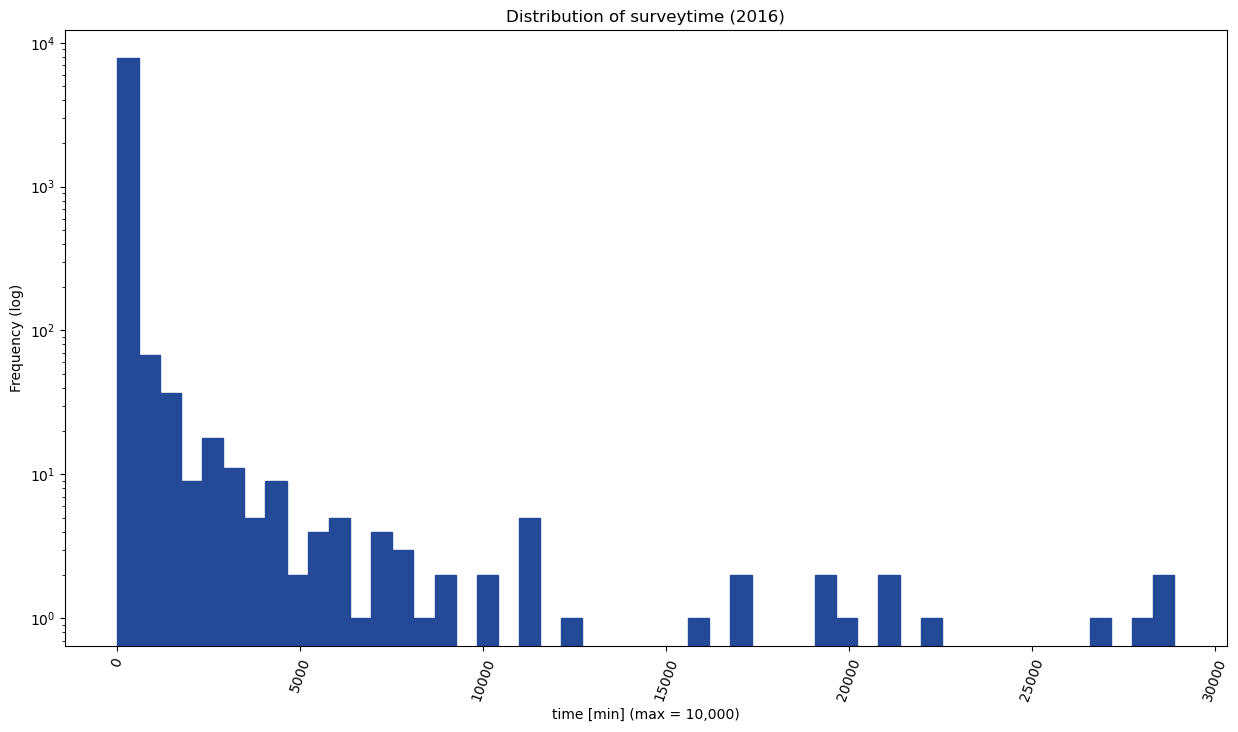

In [51]:
#244999presentation_plots/plt.figure(figsize=(15,8))
plt.hist(df["duration_minutes"], bins = 50, color = "#244999", edgecolor = "#244999" )
plt.title("Distribution of surveytime (2016)")
plt.xlabel("time [min] (max = 10,000)")
plt.xticks(rotation = 70)
#plt.xlim(0, 10000)
plt.yscale("log")
plt.ylabel("Frequency (log)")
plt.savefig("results/presentation_plots/hist_surveytime_2016.png", dpi = 300)
plt.show()

## testing some correlations

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import wilcoxon
from scipy.stats import shapiro
from scipy import stats
from scipy.stats import chi2_contingency 

In [ ]:
v1 = df.columns.values.tolist()


In [ ]:
correlation = {"Var1" : [], "Var2" : [], "chi2" :[], "p": [], "df": []}

for w in v1: 
    for fe in v1: 
        # Note: stats.pearsonr returns (correlation_coefficient, p_value)
        # Usually 'r' is used for the coefficient, 't' usually refers to a t-test statistic
        # 1. Create a frequency table (contingency table)
        contingency_table = pd.crosstab(df[w], df[fe])
        
        # 2. Run the Test of Independence
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        
        # Significant Positive
        if p < 0.05: #chi2>0.5 rausnehmen!!!
            correlation["Var1"].append(w)
            correlation["Var2"].append(fe)
            correlation["chi2"].append(round(chi2,2))
            correlation["p"].append(round(p, 3))
            correlation["df"].append(round(dof))
            #print(f"Sig. positive Correlation for {w} and {fe}: r={r:.3f}, p={p:.3f}")
            
     

cor = pd.DataFrame.from_dict(correlation)

In [ ]:
cor = pd.DataFrame.from_dict(correlation)
#cor.to_csv(path_or_buf= "C:/Users/rieke/OneDrive/Documents/FS26/datascience/project/correlation2.csv", sep=',')

In [ ]:
correlation_oc = {"Var1" : [], "Var2" : [], "chi2" :[], "p": [], "df": []}

for w in v1: 
    # Note: stats.pearsonr returns (correlation_coefficient, p_value)
    # Usually 'r' is used for the coefficient, 't' usually refers to a t-test statistic
    # 1. Create a frequency table (contingency table)
    contingency_table = pd.crosstab(df[w], df["occupation"])
    
    # 2. Run the Test of Independence
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Significant Positive
    if  p < 0.05: 
        correlation["Var1"].append(w)
        correlation["Var2"].append(fe)
        correlation["chi2"].append(round(chi2,2))
        correlation["p"].append(round(p, 3))
        correlation["df"].append(round(dof))
        #print(f"Sig. positive Correlation for {w} and {fe}: r={r:.3f}, p={p:.3f}")
            
     

cor_oc = pd.DataFrame.from_dict(correlation_oc2)

In [ ]:
cor_oc = pd.DataFrame.from_dict(correlation2)

In [ ]:
print(cor_oc)

In [ ]:
#cor_oc.to_csv(path_or_buf= "C:/Users/rieke/OneDrive/Documents/FS26/datascience/project/correlation_occupation.csv", sep=',')

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Create a frequency table (contingency table)
contingency_table = pd.crosstab(df["education"], df["occupation"])

# 2. Run the Test of Independence
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}, df = {dof}")
print(f"P-value: {p}")

## Creating some plots for the presentation

In [9]:
import matplotlib.pyplot as plt

In [5]:
# counting # Hillary & # Donald
# https://www.geeksforgeeks.org/python/how-to-count-occurrences-of-specific-value-in-pandas-column/
nC = df["presvote16post_2016"].value_counts().get('Hillary Clinton', 0)
nT = df["presvote16post_2016"].value_counts().get('Donald Trump', 0)

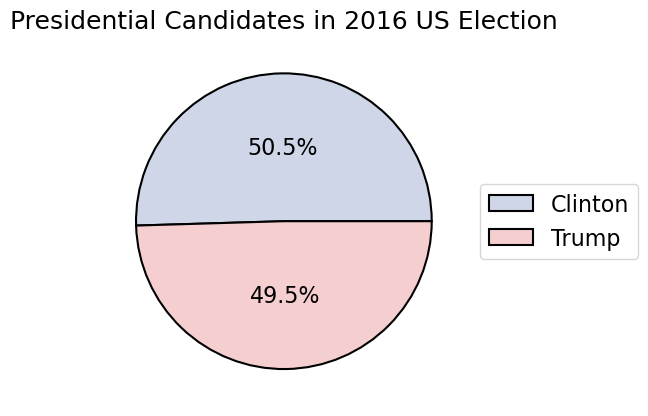

In [36]:
# https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html
sizes = [nC, nT]
labels = "Clinton", "Trump"

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    sizes,
    colors=["#CED6E8", "#F5CED0"],
    autopct='%1.1f%%',
    pctdistance=0.5,
    textprops={'fontsize': 16},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)

# Set title correctly
ax.set_title("Presidential Candidates in 2016 US Election", fontsize=18)

# Add legend (with wedges!)
ax.legend(
    wedges,
    labels,
    loc="center left",
    fontsize=16,
    bbox_to_anchor=(1, 0.5)
)

plt.savefig("results/presentation_plots/piechart_CvT_alldata", dpi=500)
plt.show()

